# 4.2 Minería de reglas y análisis de valores atípicos en conjuntos de datos

## PASO 1. Carga de los datasets

In [6]:
import pandas as pd

# Cargar datasets de SuperMarket+
catalogo = pd.read_csv("catalogo_productos.csv")
transacciones = pd.read_csv("transacciones_supermarket.csv")

# Vista general
catalogo.head(), transacciones.head()


(  product_id         categoria nombre_producto  precio
 0      P0001  Cuidado Personal      Producto_1   31.24
 1      P0002          Limpieza      Producto_2   57.04
 2      P0003             Hogar      Producto_3   20.85
 3      P0004  Cuidado Personal      Producto_4   88.08
 4      P0005           Bebidas      Producto_5  103.28,
   transaction_id product_id
 0         T00001      P0083
 1         T00001      P0028
 2         T00001      P0066
 3         T00001      P0013
 4         T00002      P0077)

## PASO 2. Convertir transacciones al formato “cesta”

In [7]:
# Construir formato cesta (basket format)
basket = (
    transacciones
    .pivot_table(
        index='transaction_id',
        columns='product_id',
        aggfunc=lambda x: 1,
        fill_value=0
    )
)

basket.head()


product_id,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,P0010,...,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099,P0100
transaction_id,,,,,,,,,,,,,,,,,,,,,
T00001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T00002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T00003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T00004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T00005,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## PASO 3. Aplicar Apriori para identificar conjuntos frecuentes

In [8]:
from mlxtend.frequent_patterns import apriori
import warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


basket_bool = basket.astype(bool)

itemsets = apriori(basket_bool, min_support=0.001, use_colnames=True)
itemsets.sort_values("support", ascending=False).head()



,support,itemsets
43,0.037000,(P0044)
73,0.036667,(P0074)
93,0.036333,(P0094)
15,0.036333,(P0016)
99,0.035333,(P0100)


## PASO 4. Generar reglas de asociación (confidence + lift)


In [9]:
from mlxtend.frequent_patterns import association_rules

# Generar reglas usando "confidence"
reglas = association_rules(itemsets, metric="confidence", min_threshold=0.3)

# Ordenar por lift
reglas_ordenadas = reglas.sort_values(by="lift", ascending=False).copy()

# Función para convertir conjunto a texto
def conjunto_a_texto(conjunto):
    return ", ".join(list(conjunto))

# Convertir frozensets a texto plano
reglas_ordenadas["antecedentes"] = reglas_ordenadas["antecedents"].apply(conjunto_a_texto)
reglas_ordenadas["consecuentes"] = reglas_ordenadas["consequents"].apply(conjunto_a_texto)

# Columnas a mostrar
cols_mostrar = ["antecedentes", "consecuentes", "support", "confidence", "lift"]

# Mostrar primeras reglas
reglas_ordenadas[cols_mostrar].head(10)


,antecedentes,consecuentes,support,confidence,lift
1,"P0072, P0008",P0062,0.001,1.000000,34.090909
4,"P0012, P0026",P0030,0.001,0.750000,29.605263
5,"P0030, P0026",P0012,0.001,1.000000,29.126214
0,"P0072, P0062",P0008,0.001,0.600000,20.930233
3,"P0012, P0030",P0026,0.001,0.600000,20.454545
7,"P0085, P0026",P0096,0.001,0.600000,20.454545
8,"P0096, P0026",P0085,0.001,0.600000,19.565217
6,"P0085, P0096",P0026,0.001,0.428571,14.610390
2,"P0062, P0008",P0072,0.001,0.500000,14.285714


## PASO 5. Visualizar las mejores reglas

In [10]:
top_reglas = reglas.sort_values(by="lift", ascending=False).head(10)

top_reglas[["antecedents", "consequents", "support", "confidence", "lift"]]


,antecedents,consequents,support,confidence,lift
1,"(P0072, P0008)",(P0062),0.001,1.000000,34.090909
4,"(P0012, P0026)",(P0030),0.001,0.750000,29.605263
5,"(P0030, P0026)",(P0012),0.001,1.000000,29.126214
0,"(P0072, P0062)",(P0008),0.001,0.600000,20.930233
3,"(P0012, P0030)",(P0026),0.001,0.600000,20.454545
7,"(P0085, P0026)",(P0096),0.001,0.600000,20.454545
8,"(P0096, P0026)",(P0085),0.001,0.600000,19.565217
6,"(P0085, P0096)",(P0026),0.001,0.428571,14.610390
2,"(P0062, P0008)",(P0072),0.001,0.500000,14.285714


## Detección de anomalías en tickets con Isolation Forest y LOF

### PASO 1. Cargar y explorar los tickets

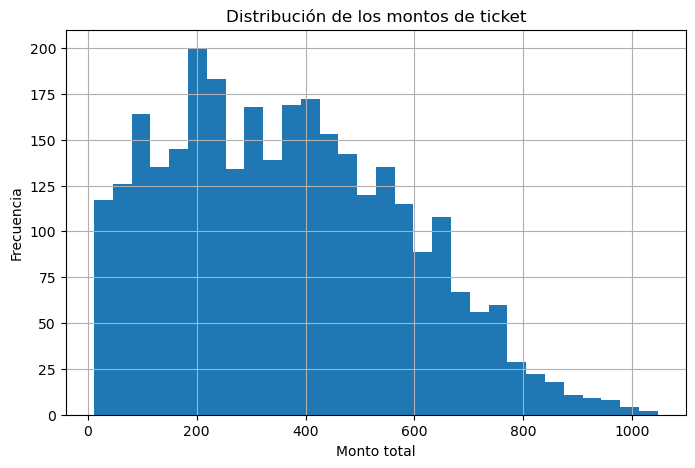

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar tickets agregados
tickets = pd.read_csv("tickets_supermarket.csv")
tickets.head()

# Resumen estadístico de los montos
tickets["monto_total"].describe().round(2)

# Histograma del monto total
plt.figure(figsize=(8,5))
plt.hist(tickets["monto_total"], bins=30)
plt.title("Distribución de los montos de ticket")
plt.xlabel("Monto total")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()


### PASO 2. Detección de anomalías con Isolation Forest

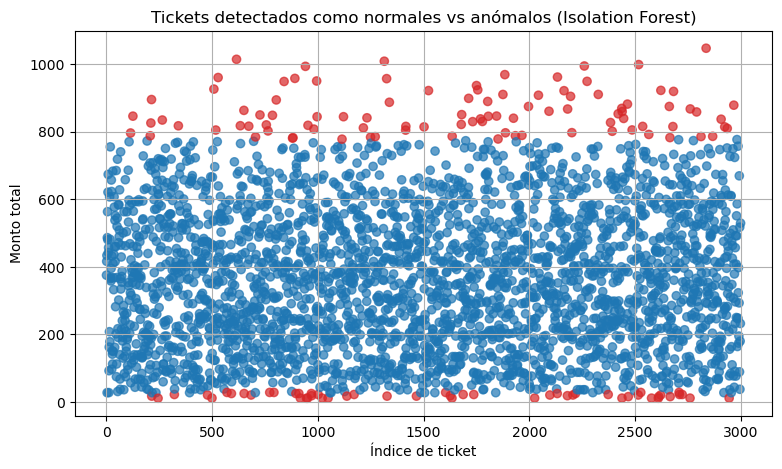

,transaction_id,monto_total,iforest_pred,iforest_score
2836,T02837,1047.24,-1,-0.186581
615,T00616,1014.43,-1,-0.181934
1314,T01315,1008.80,-1,-0.180391
2517,T02518,998.85,-1,-0.178339
2260,T02261,994.64,-1,-0.177315
941,T00942,993.62,-1,-0.177315
1884,T01885,969.10,-1,-0.169679
2133,T02134,961.91,-1,-0.164631
528,T00529,960.53,-1,-0.160618
891,T00892,957.95,-1,-0.158619


In [12]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Modelo de Isolation Forest
X = tickets[["monto_total"]]  # variable numérica

iso = IsolationForest(
    contamination=0.05,   # ~5% de tickets anómalos
    random_state=42
)

tickets["iforest_pred"] = iso.fit_predict(X)
tickets["iforest_score"] = iso.decision_function(X)
# tickets.head()



# Ver cuántos outliers detectó

tickets["iforest_pred"].value_counts()


#Visualizar
# Crear una columna booleana para colorear
colores = tickets["iforest_pred"].map({1: "normal", -1: "anomalo"})

plt.figure(figsize=(9,5))
plt.scatter(
    x=range(len(tickets)),
    y=tickets["monto_total"],
    c=tickets["iforest_pred"].map({1: "tab:blue", -1: "tab:red"}),
    alpha=0.7
)
plt.title("Tickets detectados como normales vs anómalos (Isolation Forest)")
plt.xlabel("Índice de ticket")
plt.ylabel("Monto total")
plt.grid(True)
plt.show()

# Filtrar solo los anómalos
tickets_if_anom = tickets[tickets["iforest_pred"] == -1].copy()
tickets_if_anom.sort_values("monto_total", ascending=False).head(10)



### PASO 3. Detección de anomalías con Local Outlier Factor (LOF)

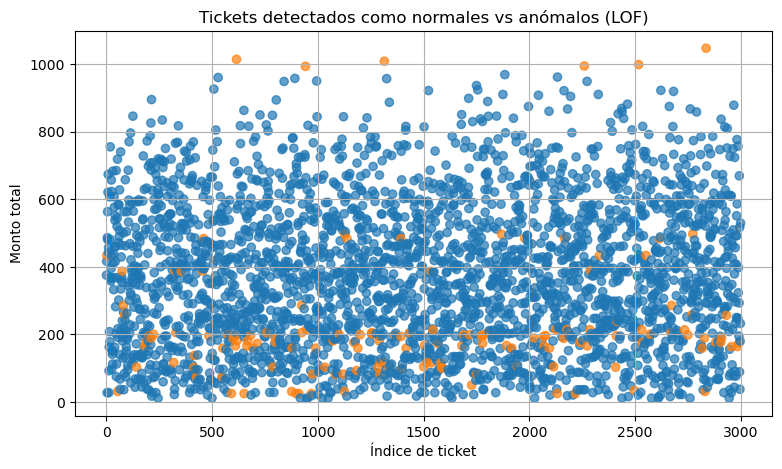

,transaction_id,monto_total,iforest_pred,iforest_score,lof_pred,lof_score
53,T00054,31.24,1,0.003729,-1,-3.961185
876,T00877,31.24,1,0.003729,-1,-3.961185
1126,T01127,31.24,1,0.003729,-1,-3.961185
2831,T02832,31.24,1,0.003729,-1,-3.961185
896,T00897,25.25,-1,-0.014732,-1,-2.949245
910,T00911,25.25,-1,-0.014732,-1,-2.949245
591,T00592,25.25,-1,-0.014732,-1,-2.949245
651,T00652,25.25,-1,-0.014732,-1,-2.949245
2132,T02133,25.25,-1,-0.014732,-1,-2.949245
2218,T02219,25.25,-1,-0.014732,-1,-2.949245


In [13]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,      # vecinos para comparar densidad
    contamination=0.05   # misma proporción de anomalías
)

tickets["lof_pred"] = lof.fit_predict(X)
tickets["lof_score"] = lof.negative_outlier_factor_
tickets.head()

#Cuántas anomalías detectó LOF
tickets["lof_pred"].value_counts()

# Visualizar
plt.figure(figsize=(9,5))
plt.scatter(
    x=range(len(tickets)),
    y=tickets["monto_total"],
    c=tickets["lof_pred"].map({1: "tab:blue", -1: "tab:orange"}),
    alpha=0.7
)
plt.title("Tickets detectados como normales vs anómalos (LOF)")
plt.xlabel("Índice de ticket")
plt.ylabel("Monto total")
plt.grid(True)
plt.show()

#Ver los tickets más anómalos según LOF
tickets_lof_anom = tickets[tickets["lof_pred"] == -1].copy()
tickets_lof_anom.sort_values("lof_score").head(10)  # más negativos = más raros


### PASO 4. Comparar resultados de Isolation Forest y LOF

In [14]:
# Tickets marcados como anómalos por ambos modelos
tickets_ambos = tickets[
    (tickets["iforest_pred"] == -1) & (tickets["lof_pred"] == -1)
]

tickets_ambos.sort_values("monto_total", ascending=False).head(10)


,transaction_id,monto_total,iforest_pred,iforest_score,lof_pred,lof_score
2836,T02837,1047.24,-1,-0.186581,-1,-2.051655
615,T00616,1014.43,-1,-0.181934,-1,-1.581577
1314,T01315,1008.80,-1,-0.180391,-1,-1.511270
2517,T02518,998.85,-1,-0.178339,-1,-1.413246
2260,T02261,994.64,-1,-0.177315,-1,-1.374462
941,T00942,993.62,-1,-0.177315,-1,-1.368012
896,T00897,25.25,-1,-0.014732,-1,-2.949245
651,T00652,25.25,-1,-0.014732,-1,-2.949245
591,T00592,25.25,-1,-0.014732,-1,-2.949245
910,T00911,25.25,-1,-0.014732,-1,-2.949245
